# **Lecture 2. Working with Directories and Files in Python**
---



# **§ 1. Module for Working with Directories**

# The **os** module provides functions for interacting with the operating system, including working with files and directories.

# The **os** module in Python provides a standard interface for interacting with the operating system. It allows programs to work with the file system, environment variables, processes, and system-level functionality in a platform-independent way (Windows, Linux, macOS).

# **File and directory management:**
# Create, delete, and rename files/directories
# Navigate the file system
# Check existence and properties of files

# **Path handling (with os.path):**

# Build file paths safely

# Get file names, extensions, directories

# Check absolute/relative paths

# Environment variables are values stored outside a program that provide configuration information to applications.

# **Environment interaction:**

# Read and set environment variables

# Process and system control:
# Run system commands

# Get process IDs and system information

In [1]:
import os

In [2]:
print(os.getenv("PATH"))

C:\Users\Dias\Desktop\Aitu\Programing for data analysis\.venv/Scripts;C:\Program Files (x86)\Common Files\Oracle\Java\java8path;C:\Program Files (x86)\Common Files\Oracle\Java\javapath;C:\Program Files\Microsoft\jdk-17.0.19.10-hotspot\bin;C:\WINDOWS\system32;C:\WINDOWS;C:\WINDOWS\System32\Wbem;C:\WINDOWS\System32\WindowsPowerShell\v1.0\;C:\WINDOWS\System32\OpenSSH\;C:\Program Files\Microsoft SQL Server\170\DTS\Binn\;C:\Program Files\dotnet\;C:\Program Files\Microsoft SQL Server\170\Tools\Binn\;C:\Program Files\Microsoft SQL Server\Client SDK\ODBC\170\Tools\Binn\;C:\Program Files\nodejs\;C:\Program Files\Docker\Docker\resources\bin;C:\Program Files\Git\cmd;C:\Program Files (x86)\cloudflared\;C:\Users\Dias\AppData\Local\Microsoft\WindowsApps;C:\Users\Dias\AppData\Local\Programs\Microsoft VS Code\bin;C:\Users\Dias\.local\bin;C:\Users\Dias\.dotnet\tools;C:\Users\Dias\AppData\Roaming\npm;C:\Users\Dias\AppData\Local\Python\bin;C:\Users\Dias\AppData\Local\Microsoft\WinGet\Packages\Gyan.FFmpeg

In [3]:
# Create a directory
os.mkdir("data")

In [4]:
# List files in a directory
files = os.listdir("data")
print(files)
print(os.listdir("."))

[]
['.ipynb_checkpoints', 'data', 'demodata.csv', 'ENG__Lecture_2_Directories_and_Files.ipynb', 'example.txt', 'example.xlsx', 'street.jpg']


# .config — hidden directory \ скрытая директория

In [5]:
# Check if a file exists
os.path.exists("example.txt")

True

In [6]:
os.path.exists("example1.txt")

False

In [7]:
# Get current working directory
os.getcwd()

'C:\\Users\\Dias\\Desktop\\Aitu\\Programing for data analysis\\week2'

In [8]:
# Join paths safely
path = os.path.join("data", "file.txt")
print(path)

data\file.txt


# This command does not create the data folder or the file.txt file. It only creates a string representing the path.

In [9]:
# Create a directory
os.mkdir("new_folder")

In [10]:
# Removing a directory
os.rmdir("new_folder")

# os.path and pathlib Modules

In [13]:
file_path = "example.txt"
print(os.path.abspath(file_path))       # Absolute path \ Абсолютный путь
print(os.path.dirname(file_path))       # Directory
print(os.path.splitext(file_path))      # ('example', '.txt')

C:\Users\Dias\Desktop\Aitu\Programing for data analysis\week2\example.txt

('example', '.txt')


# os.path.dirname(path) returns the directory part of the given path.
# In your case, file_path = "example.txt" is just a file name without any directory path.
# Therefore, os.path.dirname("example.txt") returns an empty string ('') because no directory is specified in the path.

# **pathlib** is a built-in Python module for working with file and directory paths. It provides a modern, object-oriented, and cross-platform alternative to many functions from os.path.

# **What pathlib is used for:**

# Creating and manipulating file and directory paths

# Navigating the file system

# Checking file and directory properties

# Reading from and writing to files

# Working with absolute and relative paths

# Ensuring cross-platform compatibility (Windows, Linux, macOS)

In [15]:
from pathlib import Path

p = Path("example.txt")
print(p.resolve())     # absolute path
print(p.stem, p.suffix)          # name without extension
print(p.suffix)        # extension
print(p.exists())      # True / False

C:\Users\Dias\Desktop\Aitu\Programing for data analysis\week2\example.txt
example .txt
.txt
True


# **§2. Basics of Working with Files**

# Working with files in Python is based on the built-in open() function.
# File modes:
# "r" — read mode (default)
# "w" — write mode (creates a new file or overwrites an existing one)
# "a" — append mode (adds data to the end of the file)
# "b" — binary mode
# "t" — text mode (default)

In [16]:
# Append to file
with open("example.txt", "a", encoding="utf-8") as f:
    f.write("\\Hello, Student!\\")
    f.write("\n Congratulations on your admission to the Master's program!\n")

In [17]:
# Reading from a file
with open("example.txt", "r", encoding="utf-8") as f:
    data = f.read()
print(data)

1 2 3 4 5
a b c d e\Hello, Student!\
 Congratulations on your admission to the Master's program!



In [18]:
# Reading from a file
with open("example.txt", "r", encoding="utf-8") as f:
    print(f.read())

1 2 3 4 5
a b c d e\Hello, Student!\
 Congratulations on your admission to the Master's program!



In [19]:
# writing to a file
with open("example2.txt", "w", encoding="utf-8") as f:
    f.write("Hello, Python!\t")
    f.write("Working with files.\n")

# Reading from a file
with open("example2.txt", "r", encoding="utf-8") as f:
    data = f.read()
print(data)

Hello, Python!	Working with files.



In [20]:
# Reading a file in binary mode
with open("street.jpg", "rb") as f:
    data = f.read()

print(data[:5])

print(type(data))  # <class 'bytes'>



b'\xff\xd8\xff\xe0\x00'
<class 'bytes'>


# Python does not decode the image or display its pixels here. It simply reads the file contents as a sequence of bytes.

# Python здесь не декодирует изображение и не показывает пиксели. Он просто считывает содержимое файла как последовательность байтов.

# **§3. Working with CSV (Comma-Separated Values) Files**

# We import the csv module, which provides functionality for reading and writing CSV files.

# csv.reader()
# csv.writer()
# csv.DictReader()
# csv.DictWriter()

In [21]:
import csv

# Write to CSV
with open("data.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["name", "age"])
    writer.writerow(["Aigul", 25])
    writer.writerow(["Alikhan", 30])
# Reading from CSV
with open("data.csv", "r", encoding="utf-8") as f:
    reader = csv.reader(f)
    for row in reader:
        print(row)

['name', 'age']
['Aigul', '25']
['Alikhan', '30']


In [22]:
with open("data.csv", "a", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["Amina", 22])
    writer.writerow(["Arman", 27])
    # Reading from CSV
with open("data.csv", "r", encoding="utf-8") as f:
    reader = csv.reader(f)
    for row in reader:
        print(row)

['name', 'age']
['Aigul', '25']
['Alikhan', '30']
['Amina', '22']
['Arman', '27']


In [23]:
# Deleting rows by condition (for example, by name or age)

input_file = "data.csv"
temp_data = []

# Read and filter
with open(input_file, "r", encoding="utf-8") as f:
    reader = csv.reader(f)
    for row in reader:
        if row[0] != "Amina":   # deletion condition
            temp_data.append(row)

# Rewrite file
with open(input_file, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerows(temp_data)

# Reading from CSV
with open("data.csv", "r", encoding="utf-8") as f:
    reader = csv.reader(f)
    for row in reader:
        print(row)

['name', 'age']
['Aigul', '25']
['Alikhan', '30']
['Arman', '27']


# **§4. Working with JSON Files**

# JSON (JavaScript Object Notation) - It is a text format for storing and exchanging data.

#

# **For reading data in the json module, there are two methods:**

# json.load — reads a file in JSON format and returns Python objects

# json.loads — reads a JSON-formatted string and returns Python objects

In [24]:
import json

# Writing to a JSON file
person = {"name": "Alice", "age": 25, "skills": ["Python", "AI"]}
with open("person.json", "w", encoding="utf-8") as f:
    json.dump(person, f, indent=4)

# Reading a JSON file
with open("person.json", "r", encoding="utf-8") as f:
    data = json.load(f)
print(data)

{'name': 'Alice', 'age': 25, 'skills': ['Python', 'AI']}


# indent=4 — makes the JSON "pretty formatted" with 4-space indents. Removing indent will save everything on a single line.


In [25]:
# Convert a Python object to a JSON string
import json

# create dictionary x:
x = {
"name": "Viktor",
"age": 30,
"city": "Astana"
}
# convert to JSON:
y = json.dumps(x)
# As a result, we get a JSON string:
print(y, type(y))

{"name": "Viktor", "age": 30, "city": "Astana"} <class 'str'>


# When you convert from Python to JSON, Python objects are converted to their JSON equivalent:

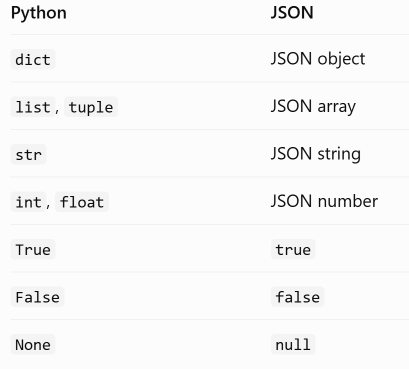

# JSON object — это формат JSON, а после json.dumps() результат имеет тип str в Python.

In [26]:
import json

student = {"name": "Viktor", "age": 30}

# Python dict → JSON string
json_data = json.dumps(student)
print(type(json_data))     # <class 'str'>

# JSON string → Python dict
python_data = json.loads(json_data)
print(type(python_data))   # <class 'dict'>

<class 'str'>
<class 'dict'>


# **§5. Working with .xlsx files**

#Working with .xlsx (Microsoft Excel) files in Python is typically done using libraries such as openpyxl, xlrd, pandas, or xlwt, depending on your needs. Here are examples of how to work with .xlsx files using the openpyxl library.

# **§ 5.1 Library openpyxl**

In [27]:
pip install openpyxl

  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)

   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------

In [28]:
import openpyxl

# Open the file .xlsx
workbook = openpyxl.load_workbook('example.xlsx')

# Select a sheet (by name)
sheet = workbook['Лист1']

# Reading a value from a cell
value = sheet['A1'].value

for row in sheet.iter_rows(min_row=2, values_only=True):
    cell1, cell2, cell3, cell4 = row
    print(f"Cell 1: {cell1}, Cell 2: {cell2}, Cell 3: {cell3}, Cell 4: {cell4}")

print()

for row in sheet.iter_rows(min_row=2, values_only=True):
    cell1, cell2, cell3, cell4 = row
    print(f"{cell1}   {cell2}   {cell3}  {cell4}")

# Closing the file
workbook.close()

Cell 1: 0, Cell 2: 0.0625, Cell 3: 1, Cell 4: 0
Cell 1: 1, Cell 2: 0.25, Cell 3: 4, Cell 4: 0.0625
Cell 1: 2, Cell 2: 0.375, Cell 3: 6, Cell 4: 0.3125
Cell 1: 3, Cell 2: 0.25, Cell 3: 4, Cell 4: 0.6875
Cell 1: 4, Cell 2: 0.0625, Cell 3: 1, Cell 4: 0.9375
Cell 1: None, Cell 2: 1, Cell 3: None, Cell 4: 1

0   0.0625   1  0
1   0.25   4  0.0625
2   0.375   6  0.3125
3   0.25   4  0.6875
4   0.0625   1  0.9375
None   1   None  1


# Example of creating and writing data to an .xlsx file:

In [43]:
import openpyxl

# Creating a new book (workbook)
workbook = openpyxl.Workbook()

# Select the default sheet
sheet = workbook.active

# Writing data into a cell
sheet['A1'] = '325'
sheet['B1'] = '645'
sheet['C1'] = '753'

# Save the book to a file
workbook.save('example0.xlsx')

# Closing the file
workbook.close()

In [46]:
import openpyxl
from openpyxl.styles import Font, Alignment
from openpyxl.utils import get_column_letter

# 1) Creating a new workbook
workbook = openpyxl.Workbook()
sheet = workbook.active
sheet.title = "Data"

# 2) Writing structured data (table-like format)
sheet.append(["Name", "Age"])
sheet.append(["Amina", 22])
sheet.append(["Arman", 27])
sheet.append(["Dias", 30])

# Formatting header
sheet["A1"].font = Font(bold=True)
sheet["B1"].font = Font(bold=True)
sheet["A1"].alignment = Alignment(horizontal="center")
sheet["B1"].alignment = Alignment(horizontal="center")

# 3) Save initial file
workbook.save("example1.xlsx")
workbook.close()



In [47]:
# -----------------------------
# Re-open and do operations
# -----------------------------
workbook = openpyxl.load_workbook("example1.xlsx")
sheet = workbook["Data"]

#  A) Deleting a cell value (clear content)
sheet["B3"].value = None   # clear Age for Amina

#  B) Deleting a row (remove Amina)
# Header = row 1 → Amina = row 2
sheet.delete_rows(2, 1)

#  C) Deleting a column (delete "Age")
sheet.delete_cols(2, 1)

#  D) Insert a new column "City"
sheet.insert_cols(2)
sheet["B1"] = "City"
sheet["B1"].font = Font(bold=True)

# Fill cities
sheet["B2"] = "Astana"
sheet["B3"] = "Almaty"

#  E) Find and update a value (if Name == "Arman")
for row in range(2, sheet.max_row + 1):
    name = sheet[f"A{row}"].value
    if name == "Arman":
        sheet[f"B{row}"] = "Astana"

#  F) Auto column width
for col in range(1, sheet.max_column + 1):
    letter = get_column_letter(col)
    max_len = 0
    for r in range(1, sheet.max_row + 1):
        val = sheet.cell(r, col).value
        if val is not None:
            max_len = max(max_len, len(str(val)))
    sheet.column_dimensions[letter].width = max(10, min(30, max_len + 2))

#  G) Add AutoFilter
sheet.auto_filter.ref = f"A1:{get_column_letter(sheet.max_column)}{sheet.max_row}"

# 4) Save result
workbook.save("example1_updated.xlsx")
workbook.close()

print("Done! Created example1.xlsx and example1_updated.xlsx")



Done! Created example1.xlsx and example1_updated.xlsx


Auto column width : Find the longest value in each column and set the column width to its length plus 2, but do not make the column narrower than 10 or wider than 30. \ Найди самое длинное значение в каждом столбце и установи ширину столбца по его длине + 2, но не делай столбец уже 10 или шире 30.

# **§ 5.2 Pandas library**

# When outputting the contents of a DataFrame object, we obtain two-dimensional tables, similar in structure to the structure of an Excel document.

In [48]:
import pandas as pd

excel_data_df = pd.read_excel('example.xlsx', sheet_name='Лист1')

# print whole sheet data
print(excel_data_df)

    xi      pi    C       F
0  0.0  0.0625  1.0  0.0000
1  1.0  0.2500  4.0  0.0625
2  2.0  0.3750  6.0  0.3125
3  3.0  0.2500  4.0  0.6875
4  4.0  0.0625  1.0  0.9375
5  NaN  1.0000  NaN  1.0000


# Pandas assigns a row label or numeric index to a DataFrame object by default when you use the read_excel() function.
# Pandas присваивает метку строки или числовой индекс объекту DataFrame по умолчанию при использовании функции read_excel().

# We can get data from a column and convert it to a list of values. Example:

In [49]:
print(excel_data_df['pi'].tolist())

[0.0625, 0.25, 0.375, 0.25, 0.0625, 1.0]


# You can specify the column names to read from an Excel file. This is useful if you need to extract data from specific table columns.
# Можно указать имена столбцов для чтения из файла Excel. Это потребуется, если нужно вывести данные из определенных столбцов таблицы.

In [ ]:
excel_data_df = pd.read_excel('example.xlsx', sheet_name='Лист1', usecols=['xi', 'F'])
print(excel_data_df)

    xi       F
0  0.0  0.0000
1  1.0  0.0625
2  2.0  0.3125
3  3.0  0.6875
4  4.0  0.9375
5  NaN  1.0000


# If the Excel sheet does not have a header row, you need to pass its value as None.
# Если в листе Excel нет строки заголовка, нужно передать его значение как None.

In [50]:
excel_data_df = pd.read_excel('example.xlsx', sheet_name='Лист2', header=2)
print(excel_data_df)

Empty DataFrame
Columns: [4, 10, -1]
Index: []


# If you pass the header value as an integer (for example, 3), then the third row will become the header. Data reading will then begin from the next row. Data located before the header row will be discarded.
# Если вы передадите значение заголовка как целое число (например, 3), тогда третья строка станет им. При этом считывание данных начнется со следующей строки. Данные, расположенные перед строкой заголовка, будут отброшены.

# The DataFrame object provides various methods for converting tabular data to Dict , CSV, or JSON format.
# Объект DataFrame предоставляет различные методы для преобразования табличных данных в формат Dict , CSV или JSON.

In [51]:
excel_data_df = pd.read_excel('example.xlsx', sheet_name='Лист1', usecols=['xi', 'pi'])

print('Excel Sheet to Dict:', excel_data_df.to_dict(orient='records'))
print('Excel Sheet to JSON:', excel_data_df.to_json(orient='records'))
print('Excel Sheet to CSV:\n', excel_data_df.to_csv(index=False))

Excel Sheet to Dict: [{'xi': 0.0, 'pi': 0.0625}, {'xi': 1.0, 'pi': 0.25}, {'xi': 2.0, 'pi': 0.375}, {'xi': 3.0, 'pi': 0.25}, {'xi': 4.0, 'pi': 0.0625}, {'xi': nan, 'pi': 1.0}]
Excel Sheet to JSON: [{"xi":0.0,"pi":0.0625},{"xi":1.0,"pi":0.25},{"xi":2.0,"pi":0.375},{"xi":3.0,"pi":0.25},{"xi":4.0,"pi":0.0625},{"xi":null,"pi":1.0}]
Excel Sheet to CSV:
 xi,pi
0.0,0.0625
1.0,0.25
2.0,0.375
3.0,0.25
4.0,0.0625
,1.0



# Let's add the cols parameter so that it reads the columns that correspond to the xi, pi values.
# Добавим параметр cols, чтобы он читал колонки, которые соответствуют значениям xi, pi.

In [ ]:
cols = [0, 1]

top_players = pd.read_excel('example.xlsx', usecols=cols)
top_players.head()

,xi,pi
0,0.0,0.0625
1,1.0,0.2500
2,2.0,0.3750
3,3.0,0.2500
4,4.0,0.0625


# **Writing to an Excel file with Python**

In [52]:
import pandas as pd

df = pd.DataFrame({'Name': ['Manchester City', 'Real Madrid', 'Liverpool',
                            'FC Bayern München', 'FC Barcelona', 'Juventus'],
                   'League': ['English Premier League (1)', 'Spain Primera Division (1)',
                              'English Premier League (1)', 'German 1. Bundesliga (1)',
                              'Spain Primera Division (1)', 'Italian Serie A (1)'],
                   'TransferBudget': [176000000, 188500000, 90000000,
                                      100000000, 180500000, 105000000]})


In [53]:
print(df)

                Name                      League  TransferBudget
0    Manchester City  English Premier League (1)       176000000
1        Real Madrid  Spain Primera Division (1)       188500000
2          Liverpool  English Premier League (1)        90000000
3  FC Bayern München    German 1. Bundesliga (1)       100000000
4       FC Barcelona  Spain Primera Division (1)       180500000
5           Juventus         Italian Serie A (1)       105000000


In [55]:
print(df.head())   # first 5 lines
print()
print(df.tail())   # last 5 lines

                Name                      League  TransferBudget
0    Manchester City  English Premier League (1)       176000000
1        Real Madrid  Spain Primera Division (1)       188500000
2          Liverpool  English Premier League (1)        90000000
3  FC Bayern München    German 1. Bundesliga (1)       100000000
4       FC Barcelona  Spain Primera Division (1)       180500000

                Name                      League  TransferBudget
1        Real Madrid  Spain Primera Division (1)       188500000
2          Liverpool  English Premier League (1)        90000000
3  FC Bayern München    German 1. Bundesliga (1)       100000000
4       FC Barcelona  Spain Primera Division (1)       180500000
5           Juventus         Italian Serie A (1)       105000000


In [56]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Name            6 non-null      object
 1   League          6 non-null      object
 2   TransferBudget  6 non-null      int64 
dtypes: int64(1), object(2)
memory usage: 276.0+ bytes
None


# You can change the sheet name by adding the sheet_name parameter to the to_excel() call:
# Поменять название листа можно, добавив параметр sheet_name в вызов to_excel():

In [57]:
df.to_excel('example1.xlsx', sheet_name='Budgets', index=False)
top_players = pd.read_excel('example1.xlsx')
top_players.head(10)

,Name,League,TransferBudget
0,Manchester City,English Premier League (1),176000000
1,Real Madrid,Spain Primera Division (1),188500000
2,Liverpool,English Premier League (1),90000000
3,FC Bayern München,German 1. Bundesliga (1),100000000
4,FC Barcelona,Spain Primera Division (1),180500000
5,Juventus,Italian Serie A (1),105000000


# It's also possible to write multiple DataFrames to an Excel file. To do this, you can specify a separate sheet for each object. To create a writer object using the XlsxWriter library in Python, you must first install the library if it isn't already installed.You can then use XlsxWriter to create and write data to an Excel file. Here's an example of creating a writer object and appending data to a file.

## Также есть возможность записать несколько DataFrame в файл Excel. Для этого можно указать отдельный лист для каждого объекта. Для создания объекта writer с помощью библиотеки XlsxWriter в Python, вы должны сначала установить библиотеку, если она еще не установлена. Затем вы можете использовать XlsxWriter для создания и записи данных в файл Excel. Вот пример создания объекта writer и добавления данных в файл.

In [58]:
pip install XlsxWriter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 3.2 MB/s eta 0:00:00


In [59]:
import xlsxwriter

salaries1 = pd.DataFrame({'Name': ['L. Messi', 'Cristiano Ronaldo', 'J. Oblak'],
                                        'Salary': [560000, 220000, 125000]})

salaries2 = pd.DataFrame({'Name': ['K. De Bruyne', 'Neymar Jr', 'R. Lewandowski'],
                                        'Salary': [370000, 270000, 240000]})

salaries3 = pd.DataFrame({'Name': ['Alisson', 'M. ter Stegen', 'M. Salah'],
                                        'Salary': [160000, 260000, 250000]})

salary_sheets = {'Group1': salaries1, 'Group2': salaries2, 'Group3': salaries3}

writer = pd.ExcelWriter('example2.xlsx', engine='xlsxwriter')

for sheet_name in salary_sheets.keys():
    salary_sheets[sheet_name].to_excel(writer, sheet_name=sheet_name, index=False)

writer.close()

# index=False prevents pandas from riting the DataFrame index as an additional column in the Excel file.

In [60]:
top_players = pd.read_excel('example2.xlsx')
top_players.head()

,Name,Salary
0,L. Messi,560000
1,Cristiano Ronaldo,220000
2,J. Oblak,125000


In [61]:
top_players = pd.read_excel('example2.xlsx', sheet_name='Group2')
top_players.head()

,Name,Salary
0,K. De Bruyne,370000
1,Neymar Jr,270000
2,R. Lewandowski,240000


# Pandas assigns a row label or numeric index to a DataFrame object by default when using the read_excel() function.
# This behavior can be overridden by passing one of the columns from the file as the index_col parameter:

Pandas присваивает метку строки или числовой индекс объекту DataFrame по умолчанию при использовании функции read_excel().

Это поведение можно переписать, передав одну из колонок из файла в качестве параметра index_col:



In [62]:
top_players = pd.read_excel('example2.xlsx', index_col='Name')
top_players.head()

,Salary
Name,
L. Messi,560000
Cristiano Ronaldo,220000
J. Oblak,125000


# **§6. Archiving and Working with Different File Formats**

# The zipfile and tarfile modules help you work with archives.

# **6.1 What is a zipfile?**

# zipfile is a built-in Python module that allows you to:
# create ZIP archives,
# add files to them,
# extract files,
# view the contents of a ZIP archive.

zipfile — это встроенный модуль Python, который позволяет:
создавать ZIP-архивы,
добавлять в них файлы,
извлекать файлы,
просматривать содержимое ZIP-архива.

# ZIP — one of the most popular archiving formats

In [63]:
import zipfile

# Creating an archive
with zipfile.ZipFile("archive.zip", "w") as zf:
    zf.write("example.txt")

In [64]:
# Extracting the archive
with zipfile.ZipFile("archive.zip", "r") as zf:
    zf.extractall("unzipped_folder")

# By default, zipfile uses ZIP_STORED (no compression).   
По умолчанию zipfile использует ZIP_STORED (без сжатия).

# You can enable compression: Можно включить сжатие:

In [65]:
with zipfile.ZipFile("archive.zip", "w", compression=zipfile.ZIP_DEFLATED) as zf:
    zf.write("example.txt")

# Available Algorithms:

# ZIP_STORED — no compression
# ZIP_DEFLATED — standard DEFLATE algorithm (need zlib)
# ZIP_BZIP2 —  bzip2 compression
# ZIP_LZMA — LZMA compression

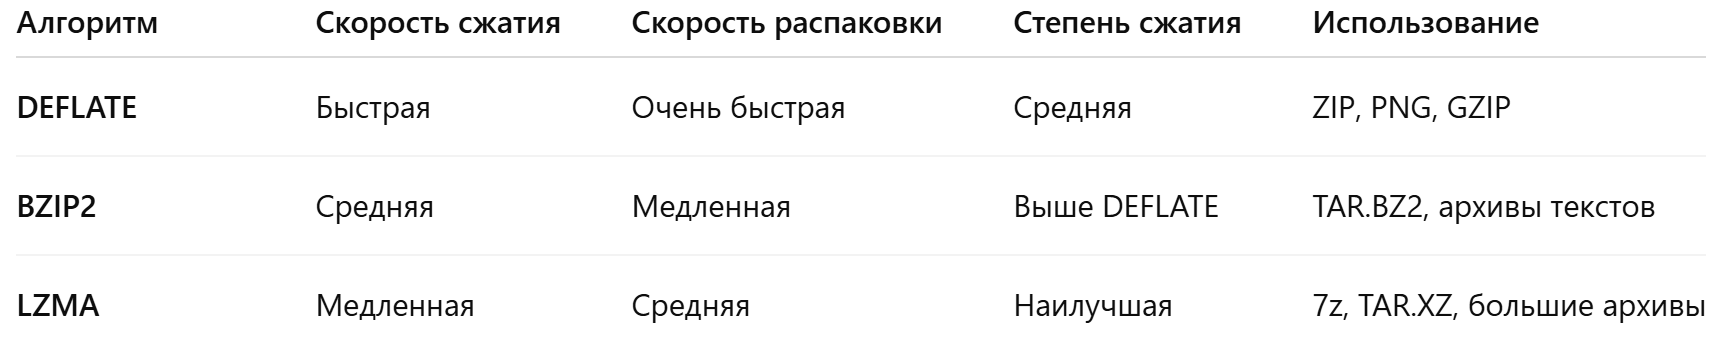

# **6.2 Module tarfile**

# Python has a built-in tarfile module that allows you to work with TAR archives and their compressed versions.:

# .tar (uncompressed)
# .tar.gz или .tgz ( gzip compression)
# .tar.bz2 ( bzip2 compression)
# .tar.xz ( xz compression)

# So, tarfile is not a type of archive, but a library for working with the TAR format.

# TAR itself doesn't compress data—it simply "glues" multiple files and folders into a single archive (container).

# To reduce size, TAR is usually additionally compressed using the following algorithms:

TAR сам по себе не сжимает данные — он просто «склеивает» несколько файлов и папок в один архив (container).

Чтобы уменьшить размер, TAR обычно дополнительно сжимают алгоритмами:

# Gzip → .tar.gz, .tgz
# Bzip2 → .tar.bz2, .tbz
# XZ → .tar.xz, .txz

# **Tarfile archive modes**


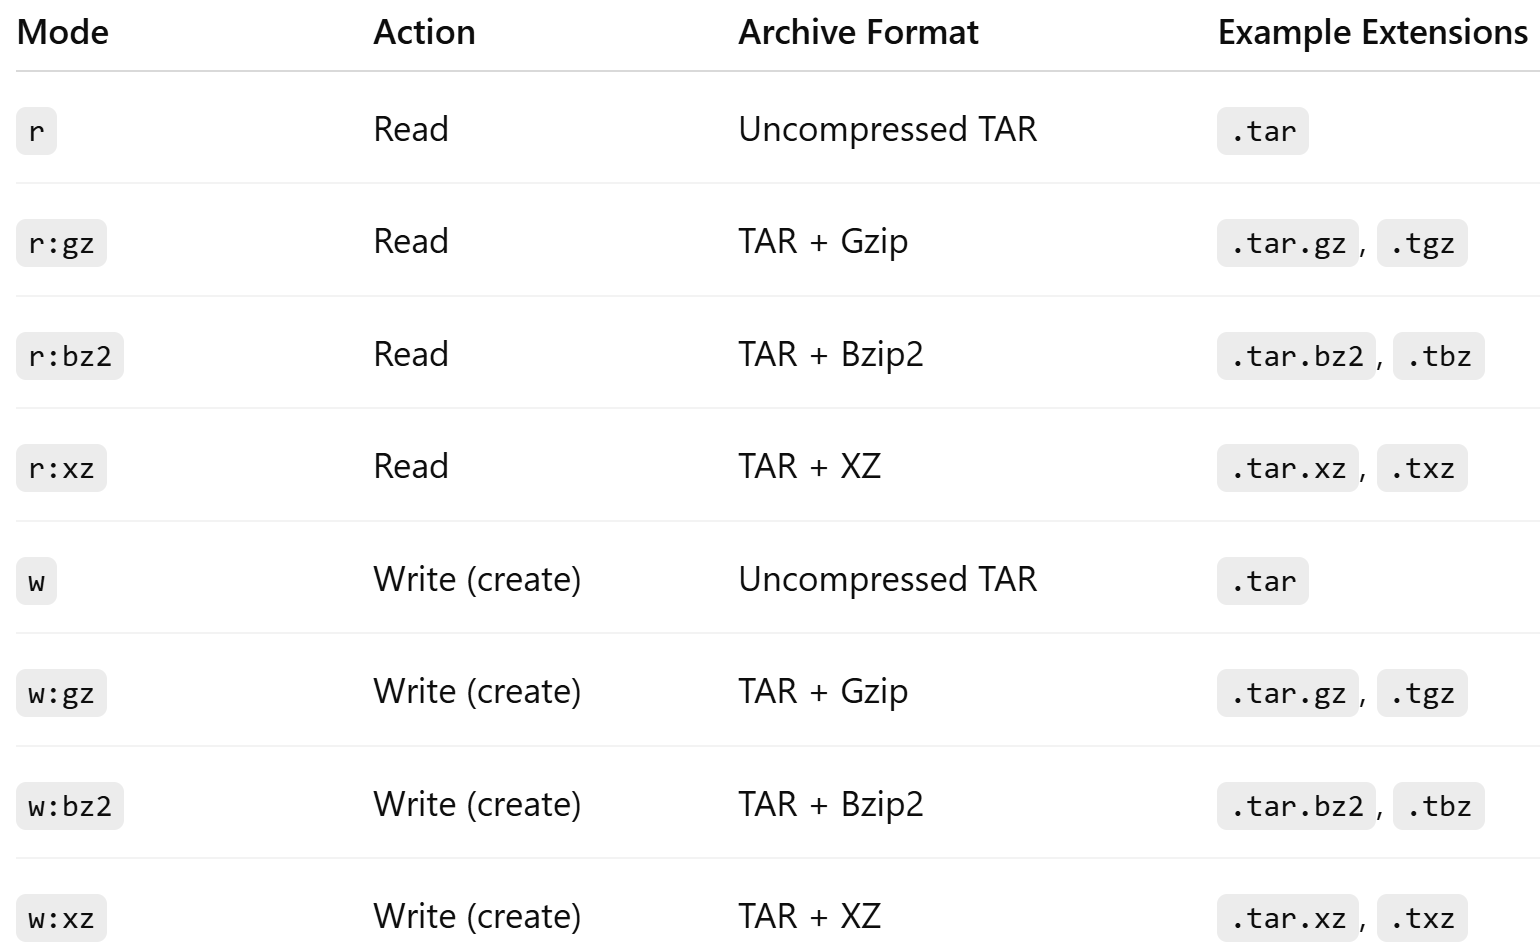

In [67]:
import tarfile

# Creating an archive
with tarfile.open("archive.tar.gz", "w:gz") as tf:
    tf.add("demodata.csv")


In [68]:
# Extracting the archive
with tarfile.open("archive.tar.gz", "r:gz") as tf:
    tf.extractall("output_folder")

/tmp/ipykernel_2957/358089780.py:3: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tf.extractall("output_folder")


# **What is the difference between TAR and ZIP?**

# ZIP = packaging + compression of each file separately.

# TAR = packaging all files into a single container → then the whole archive is compressed as one unit (using gzip, bzip2, etc.).

# Therefore, .tar.gz archives are often more compact than .zip files and faster to extract on Linux/Unix systems.

# **В чём отличие TAR от ZIP? **
# ZIP = упаковка + сжатие каждого файла отдельно.
# TAR = упаковка всех файлов в один контейнер → потом общий архив сжимается целиком (gzip, bzip2 и т.д.).
# Поэтому .tar.gz часто компактнее, чем .zip, и быстрее в распаковке на Linux/Unix.